In [3]:
import numpy as np
import polars as pl
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [4]:
import polars as pl

inicial = (
    pl.scan_parquet(r"C:\Users\diogo.durao\Documents\covid_rj.parquet")
    .with_columns(
        pl.col("paciente_idade").cast(pl.Int64, strict=False),
        pl.col("paciente_dataNascimento").str.to_date("%Y-%m-%d", strict=False),
        pl.col("vacina_dataAplicacao").str.to_date("%Y-%m-%d", strict=False)
    )
)

display(inicial.collect().head())

document_id,paciente_id,paciente_idade,paciente_dataNascimento,paciente_enumSexoBiologico,paciente_racaCor_codigo,paciente_racaCor_valor,paciente_endereco_coIbgeMunicipio,paciente_endereco_coPais,paciente_endereco_nmMunicipio,paciente_endereco_nmPais,paciente_endereco_uf,paciente_endereco_cep,paciente_nacionalidade_enumNacionalidade,estabelecimento_valor,estabelecimento_razaoSocial,estalecimento_noFantasia,estabelecimento_municipio_codigo,estabelecimento_municipio_nome,estabelecimento_uf,vacina_grupoAtendimento_codigo,vacina_grupoAtendimento_nome,vacina_categoria_codigo,vacina_categoria_nome,vacina_lote,vacina_fabricante_nome,vacina_fabricante_referencia,vacina_dataAplicacao,vacina_descricao_dose,vacina_codigo,vacina_nome,sistema_origem
str,str,i64,date,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,date,str,str,str,str
"""436b4b52-1e20-41b0-bc2b-0a2e4b…","""333ec2c1d748f880e61248eece8c06…",60,1963-12-14,"""F""","""99""","""SEM INFORMACAO""","""330490""","""10""","""SAO GONCALO""","""BRASIL""","""RJ""","""24421""","""B""","""2291533""","""SECRETARIA MUNICIPAL DE SAUDE …","""POLO SANITARIO DR WASHINGTON L…","""330490""","""SAO GONCALO""","""RJ""","""000210""","""Faixa Etária""","""2""","""Faixa Etária""","""2401270/00""","""BUTANTAN""","""152""",2024-06-20,"""Única""","""33""","""INF3""","""Novo PNI"""
"""d2a4632a-9906-4d9d-9e37-239fee…","""67e6e5bd91f070cac662d36f01484f…",70,1951-11-01,"""F""","""02""","""PRETA""","""330100""","""10""","""CAMPOS DOS GOYTACAZES""","""BRASIL""","""RJ""","""None""","""B""","""6298109""","""SECRETARIA MUNICIPAL DE SAUDE …","""SECRETARIA MUNICIPAL DE SAUDE …","""330100""","""CAMPOS DOS GOYTACAZES""","""RJ""","""000202""","""Pessoas de 65 a 69 anos""","""2""","""Faixa Etária""","""FF2592""","""PFIZER""","""Organization/28290""",2021-11-11,"""Reforço""","""87""","""COVID-19 PFIZER - COMIRNATY""","""Novo PNI"""
"""436be4ab-8b6b-4517-984e-e3b3af…","""ec0c977862379ec1e6cb1da87eed27…",41,1980-01-03,"""M""","""99""","""SEM INFORMACAO""","""330455""","""10""","""RIO DE JANEIRO""","""BRASIL""","""RJ""","""None""","""B""","""9307265""","""SMS RIO CF MARIA JOSE PAPERA D…","""SMS CF MARIA JOSE PAPERA DE AZ…","""330455""","""RIO DE JANEIRO""","""RJ""","""000201""","""Pessoas de 18 a 64 anos""","""2""","""Faixa Etária""","""1855836""","""JANSSEN""","""30587""",2021-12-13,"""Reforço""","""88""","""COVID-19 JANSSEN - Ad26.COV2.S""","""Novo PNI"""
"""d2a529c8-9a07-4b70-ad71-e9b864…","""bd8a7396dcae6088da675334005798…",26,1995-04-17,"""M""","""03""","""PARDA""","""330045""","""10""","""BELFORD ROXO""","""BRASIL""","""RJ""","""26183""","""B""","""2289385""","""SMS BELFORD ROXO""","""PRS PARQUE SAO JOSE""","""330045""","""BELFORD ROXO""","""RJ""","""000201""","""Pessoas de 18 a 64 anos""","""2""","""Faixa Etária""","""FD7222""","""PFIZER""","""Organization/00394544000851""",2021-10-21,"""2ª Dose""","""87""","""COVID-19 PFIZER - COMIRNATY""","""Novo PNI"""
"""436d60f1-c035-469c-929d-a5ad86…","""c0bd4a54318149959904e7ce5da15a…",24,1997-09-04,"""F""","""04""","""AMARELA""","""330100""","""10""","""CAMPOS DOS GOYTACAZES""","""BRASIL""","""RJ""","""28110""","""B""","""6298109""","""SECRETARIA MUNICIPAL DE SAUDE …","""SECRETARIA MUNICIPAL DE SAUDE …","""330100""","""CAMPOS DOS GOYTACAZES""","""RJ""","""000201""","""Pessoas de 18 a 64 anos""","""2""","""Faixa Etária""","""218VCD264W""","""ASTRAZENECA/FIOCRUZ""","""Organization/33781055000135""",2021-09-28,"""2ª Dose""","""85""","""COVID-19 ASTRAZENECA/FIOCRUZ -…","""Novo PNI"""


Dados para plotagem:
         Mes  Qtd_Vacinas
0 2021-01-01        51309
1 2021-02-01       119028
2 2021-03-01       261327
3 2021-04-01       547287
4 2021-05-01       414106


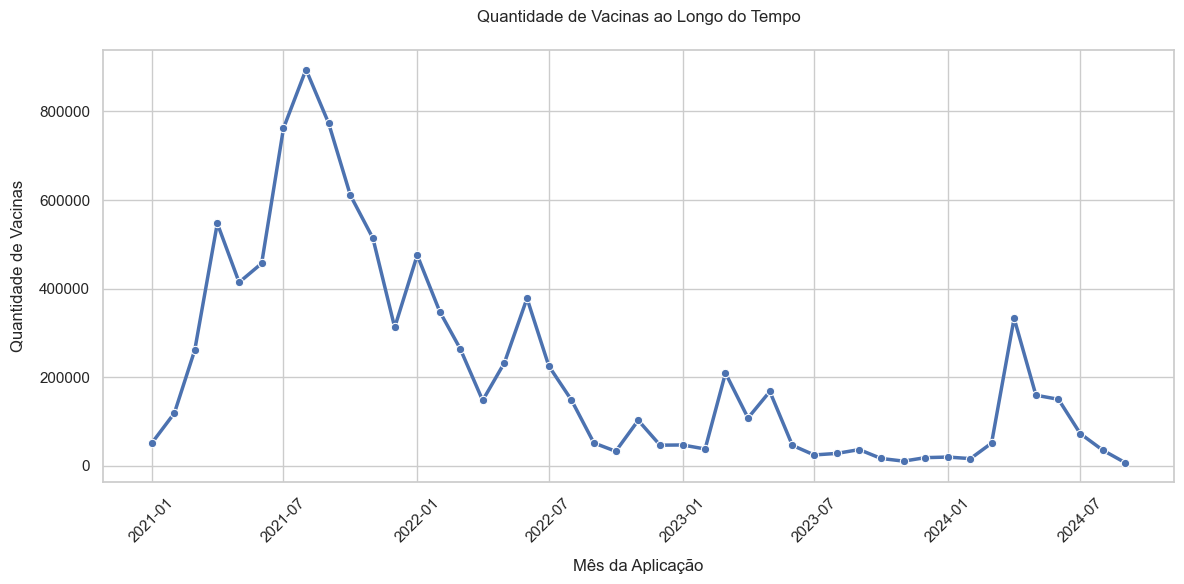

In [8]:
# Certifique-se que os dados estão corretamente agrupados

df_agrupado = inicial.filter(
pl.col("vacina_dataAplicacao") >= pl.date(2021, 1, 1)
).group_by(
pl.col("vacina_dataAplicacao").dt.truncate("1mo").alias("Mes")
).agg(
pl.len().alias("Qtd_Vacinas")
).sort("Mes").collect()

# Converter para Pandas explicitamente
df_plot = df_agrupado.to_pandas()

# Verificar os dados que serão plotados
print("Dados para plotagem:")
print(df_plot.head())

# Configurar o estilo do seaborn
sns.set_theme(style="whitegrid")

# Criar a figura e o eixo explicitamente
fig, ax = plt.subplots(figsize=(12, 6))

# Plotar usando seaborn
sns.lineplot(
data=df_plot,
x="Mes",
y="Qtd_Vacinas",
ax=ax,
marker='o',
linewidth=2.5
)

# Configurações adicionais
ax.set_title("Quantidade de Vacinas ao Longo do Tempo", pad=20)
ax.set_xlabel("Mês da Aplicação", labelpad=10)
ax.set_ylabel("Quantidade de Vacinas", labelpad=10)
ax.tick_params(axis='x', rotation=45)

# Ajustar layout para evitar cortes
plt.tight_layout()
plt.show()

In [11]:
# 1. Converter para tipo Date do Polars se necessário
if df_agrupado["Mes"].dtype != pl.Date:
    df_agrupado = df_agrupado.with_columns(
        pl.col("Mes").cast(pl.Date)
    )

# 2. Calcular usando expressões puras do Polars
df_reg = df_agrupado.with_columns(
    (pl.col("Mes").dt.year() * 12 + pl.col("Mes").dt.month() - 
     (pl.col("Mes").min().dt.year() * 12 + pl.col("Mes").min().dt.month()))
    .alias("MESES_DESDE_INICIO")
)

# 3. Verificar o resultado
print(df_reg.select(["Mes", "MESES_DESDE_INICIO"]).head())

shape: (5, 2)
┌────────────┬────────────────────┐
│ Mes        ┆ MESES_DESDE_INICIO │
│ ---        ┆ ---                │
│ date       ┆ i32                │
╞════════════╪════════════════════╡
│ 2021-01-01 ┆ 0                  │
│ 2021-02-01 ┆ 1                  │
│ 2021-03-01 ┆ 2                  │
│ 2021-04-01 ┆ 3                  │
│ 2021-05-01 ┆ 4                  │
└────────────┴────────────────────┘


Equação da reta: Qtd_Vacinas = -11188.14 * MESES_DESDE_INICIO + 463127.67
Coeficiente angular (vacinas/mês): -11188.14
Intercepto (quantidade inicial): 463127.67

Métricas de avaliação:
Coeficiente de Determinação (R²): 0.4046
Erro Quadrático Médio (MSE): 31069945670.77


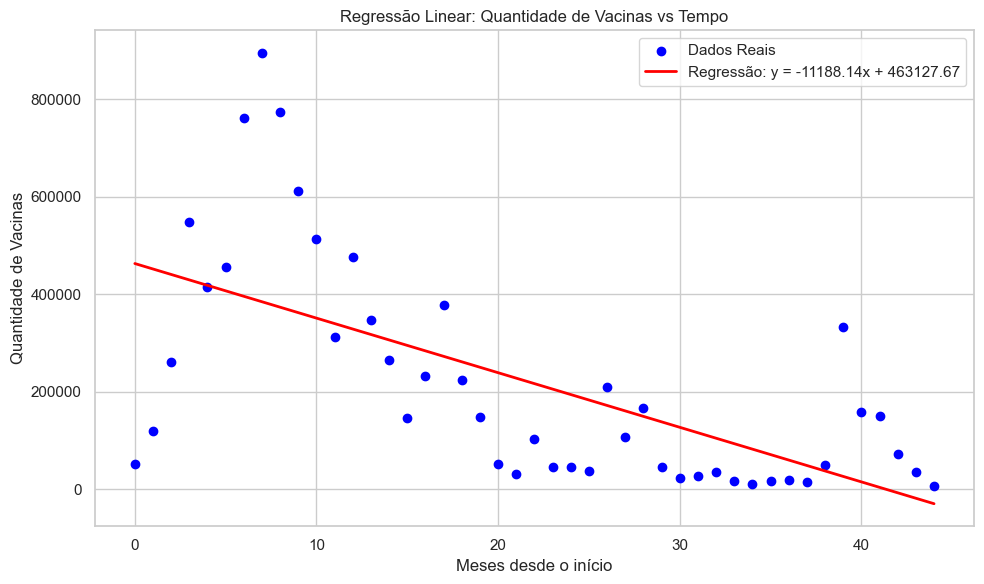

In [13]:
## 1. Preparar os dados para o modelo
X = df_reg["MESES_DESDE_INICIO"].to_numpy().reshape(-1, 1)
y = df_reg["Qtd_Vacinas"].to_numpy()

## 2. Criar e treinar o modelo
modelo = LinearRegression()
modelo.fit(X, y)

inclinacao = modelo.coef_[0]
intercepto = modelo.intercept_

print(f"Equação da reta: Qtd_Vacinas = {inclinacao:.2f} * MESES_DESDE_INICIO + {intercepto:.2f}")
print(f"Coeficiente angular (vacinas/mês): {inclinacao:.2f}")
print(f"Intercepto (quantidade inicial): {intercepto:.2f}")

## 3. Fazer previsões
y_pred = modelo.predict(X)

## 4. Avaliar o modelo
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print(f"\nMétricas de avaliação:")
print(f"Coeficiente de Determinação (R²): {r2:.4f}")
print(f"Erro Quadrático Médio (MSE): {mse:.2f}")

## 5. Visualização dos resultados
plt.figure(figsize=(10, 6))

plt.scatter(X, y, color='blue', label='Dados Reais')

plt.plot(X, y_pred, color='red', linewidth=2, label=f'Regressão: y = {inclinacao:.2f}x + {intercepto:.2f}')

plt.title('Regressão Linear: Quantidade de Vacinas vs Tempo')
plt.xlabel('Meses desde o início')
plt.ylabel('Quantidade de Vacinas')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

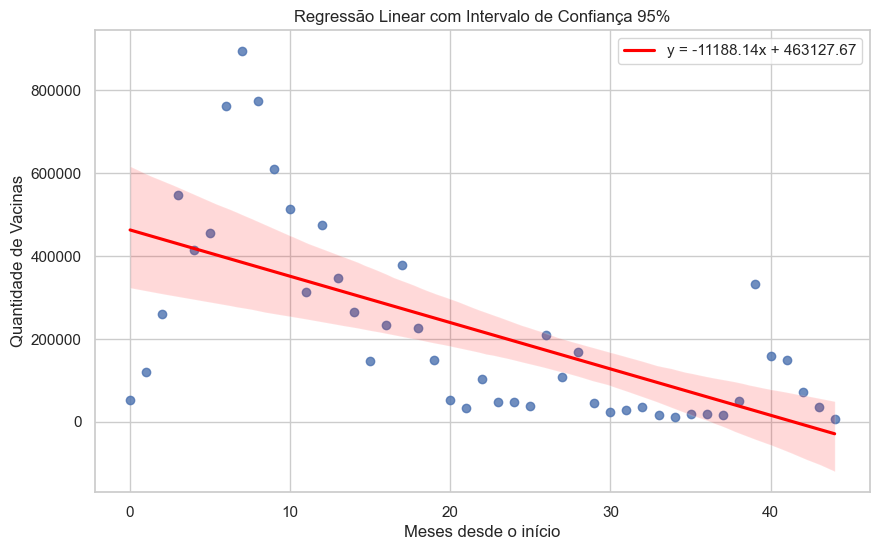

In [14]:
# Versão Alternativa com intervalo de confiança:

plt.figure(figsize=(10, 6))

sns.regplot(
    x=X.flatten(),
    y=y,
    ci=95,
    line_kws={
        'color': 'red',
        'label': f'y = {inclinacao:.2f}x + {intercepto:.2f}'
    }
)

plt.title('Regressão Linear com Intervalo de Confiança 95%')

plt.xlabel('Meses desde o início')

plt.ylabel('Quantidade de Vacinas')

plt.legend()

plt.grid(True)

plt.show()